In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('airbnb.csv',encoding_errors = 'ignore')

In [3]:
data.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20/12/15,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  str    
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  str    
 4   neighbourhood_group             20770 non-null  str    
 5   neighbourhood                   20763 non-null  str    
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  str    
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_review                     20763 non-n

In [5]:
data.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      7
latitude                           7
longitude                          7
room_type                          7
price                             34
minimum_nights                     7
number_of_reviews                  7
last_review                        7
reviews_per_month                  7
calculated_host_listings_count     7
availability_365                   7
number_of_reviews_ltm              7
license                            0
rating                             0
bedrooms                           0
beds                               0
baths                              0
dtype: int64

In [6]:
data.dropna(inplace=True)
data.isnull().sum()        # all the rows with null values have been dropped successfully

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(12)

In [8]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()     # now duplicate values have been removed

np.int64(0)

# Univariate analysis

<Axes: xlabel='price', ylabel='Count'>

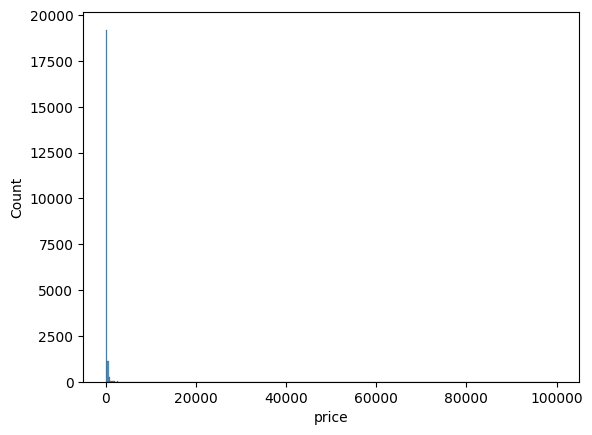

In [9]:
sns.histplot(data['price'])

<Axes: xlabel='price'>

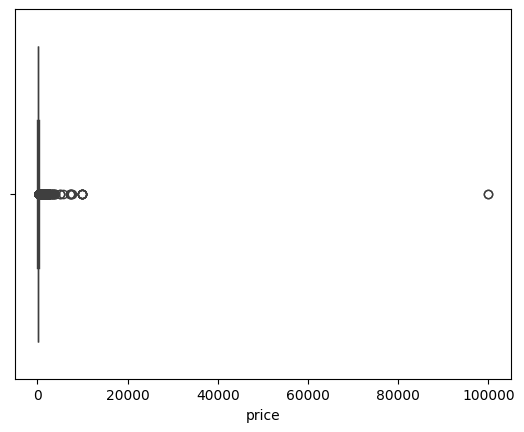

In [10]:
sns.boxplot(x=data['price'])

<Axes: xlabel='price'>

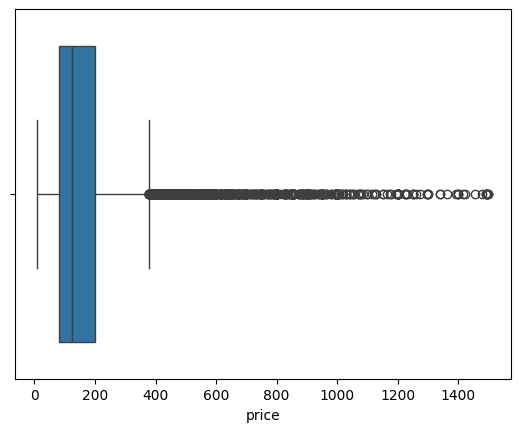

In [11]:
df = data[data['price']<1500]
sns.boxplot(x=df['price'])

Text(0, 0.5, 'frequency')

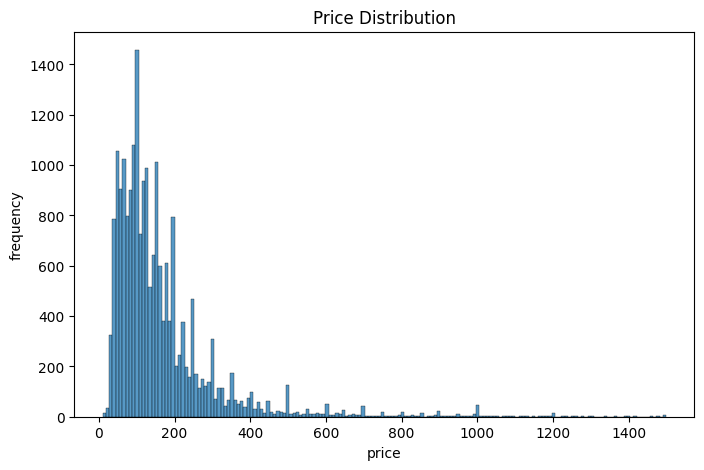

In [12]:
plt.figure(figsize= (8,5))
sns.histplot(df['price'])
plt.title('Price Distribution')
plt.ylabel('frequency')

Text(0, 0.5, 'frequency')

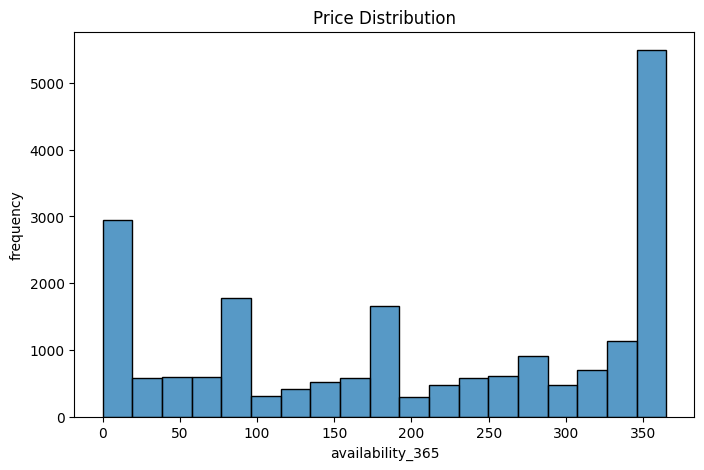

In [13]:
plt.figure(figsize= (8,5))
sns.histplot(df['availability_365'])
plt.title('Price Distribution')
plt.ylabel('frequency')

In [14]:
df.groupby('neighbourhood_group')['price'].mean()

neighbourhood_group
Bronx            107.990506
Brooklyn         155.138317
Manhattan        204.146014
Queens           121.681939
Staten Island    118.780069
Name: price, dtype: float64

# Bivariate analysis

<Axes: xlabel='neighbourhood_group', ylabel='price'>

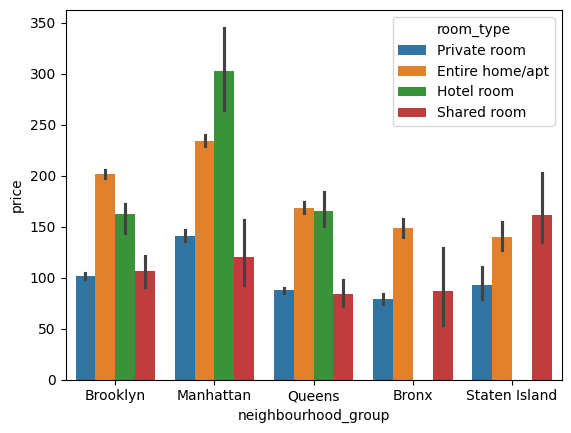

In [15]:
sns.barplot(x=df['neighbourhood_group'],y=df['price'],hue=df['room_type'])

In [16]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='str')

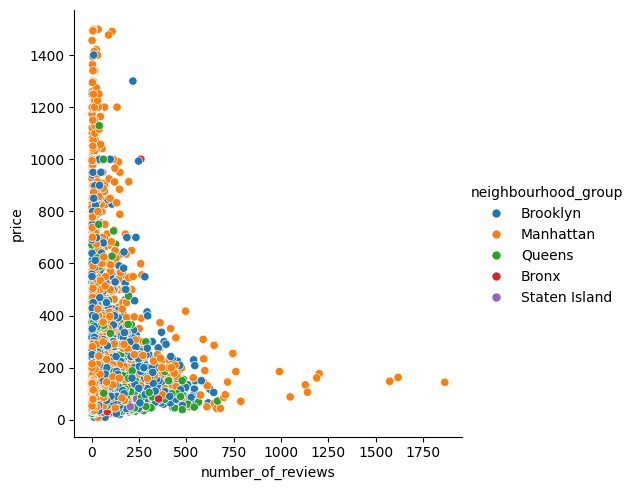

In [17]:
sns.relplot(kind='scatter',x='number_of_reviews',y='price',data=df,hue='neighbourhood_group')

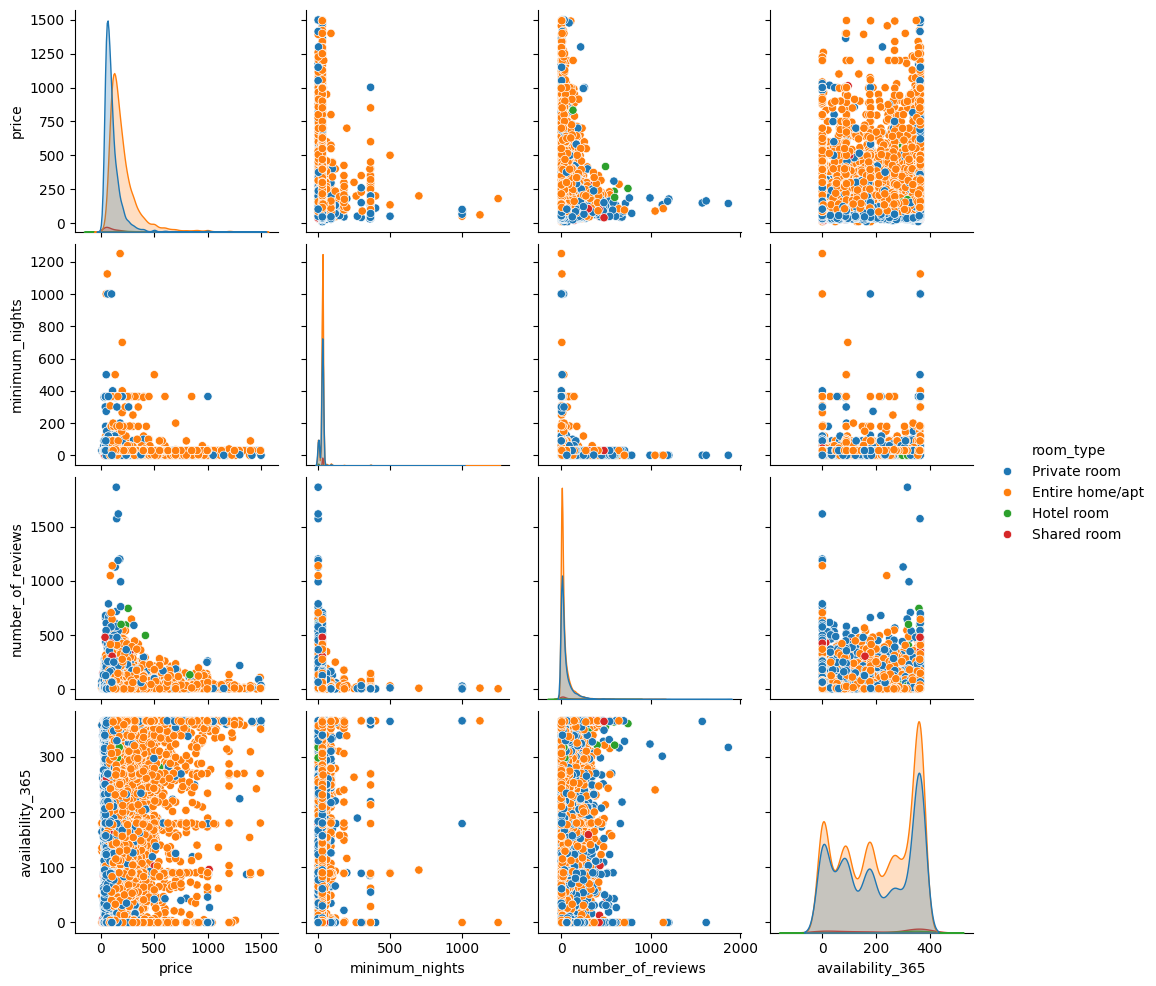

In [18]:
sns.pairplot(data=df,vars=['price', 'minimum_nights', 'number_of_reviews', 'availability_365'], hue='room_type')

### Geographical distribution of airbnb listing

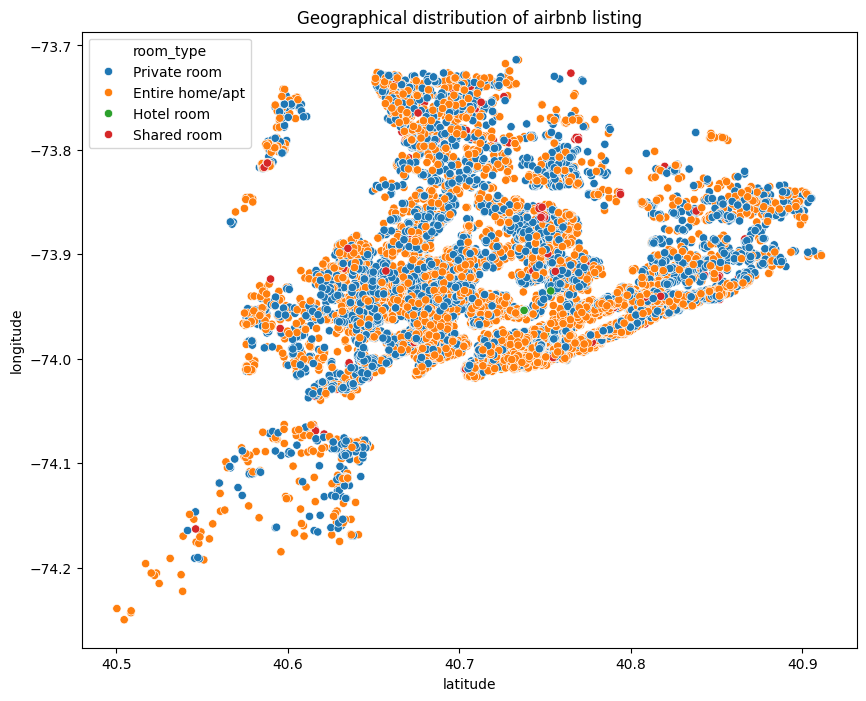

In [19]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='latitude', y='longitude', hue='room_type')
plt.title('Geographical distribution of airbnb listing')
plt.show()

### heatmap - correlation of one variable with others for numerical column

In [20]:
df.dtypes

id                                float64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                                str
bedrooms                              str
beds                                int64
baths                                 str
dtype: object

In [21]:
corr = df[['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','availability_365','beds']].corr()
corr

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,beds
latitude,1.000000,0.047369,0.012686,0.004590,-0.047953,-0.041673,-0.005941,-0.071753
longitude,0.047369,1.000000,-0.193728,0.023890,0.004820,0.041720,0.063523,0.041832
price,0.012686,-0.193728,1.000000,-0.044635,-0.043533,-0.012775,0.048036,0.415278
minimum_nights,0.004590,0.023890,-0.044635,1.000000,-0.059049,-0.122509,0.035466,-0.025852
number_of_reviews,-0.047953,0.004820,-0.043533,-0.059049,1.000000,0.631005,-0.049656,0.040071
reviews_per_month,-0.041673,0.041720,-0.012775,-0.122509,0.631005,1.000000,-0.040116,0.053496
availability_365,-0.005941,0.063523,0.048036,0.035466,-0.049656,-0.040116,1.000000,0.065985
beds,-0.071753,0.041832,0.415278,-0.025852,0.040071,0.053496,0.065985,1.000000
